<a href="https://colab.research.google.com/github/akshaykumar2972/Banking-Data-Analysis/blob/main/Banking_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Importing the required libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### **Importing the data from .CSV file**

In [ ]:
df = pd.read_csv('/content/logistic_regression.csv').drop_duplicates()
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [ ]:
df.shape

(396030, 27)

### **Data Transformation**

In [ ]:
df.iloc[:,:11].head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,Not Verified
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,Not Verified
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,Source Verified
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,Not Verified
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,Verified


In [ ]:
df['loan_amnt'] = df['loan_amnt'].astype(int)

In [ ]:
df['term'] = df['term'].apply(lambda x: int(x.split()[0]))

In [ ]:
df['emp_length'] = df['emp_length'].replace({'< 1 year': '0.5 years', '10+ years': '12 years'})

In [ ]:
df['emp_length'].value_counts()

,count
emp_length,
12 years,126041
2 years,35827
0.5 years,31725
3 years,31665
5 years,26495
1 year,25882
4 years,23952
6 years,20841
7 years,20819


In [ ]:
df['emp_length'] = pd.to_numeric(df['emp_length'].str.extract(r'(\d+\.?\d*)')[0])

In [ ]:
df.iloc[:,:11].head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status
0,10000,36,11.44,329.48,B,B4,Marketing,12.0,RENT,117000.0,Not Verified
1,8000,36,11.99,265.68,B,B5,Credit analyst,4.0,MORTGAGE,65000.0,Not Verified
2,15600,36,10.49,506.97,B,B3,Statistician,0.5,RENT,43057.0,Source Verified
3,7200,36,6.49,220.65,A,A2,Client Advocate,6.0,RENT,54000.0,Not Verified
4,24375,60,17.27,609.33,C,C5,Destiny Management Inc.,9.0,MORTGAGE,55000.0,Verified


In [ ]:
df.rename(columns={'loan_amnt':'loan_amount_requested'
                  ,'int_rate':'interest_rate'
                  ,'grade':'assigned_loan_grade'
                  ,'sub_grade':'assigned_loan_subgrade'
                  ,'emp_title':'occupation'
                  ,'emp_length':'years_of_experience'
                  ,'annual_inc':'annual_income'}, inplace=True)

In [ ]:
df.iloc[:,11:20].head()

,issue_d,loan_status,purpose,title,dti,earliest_cr_line,open_acc,pub_rec,revol_bal
0,Jan-2015,Fully Paid,vacation,Vacation,26.24,Jun-1990,16.0,0.0,36369.0
1,Jan-2015,Fully Paid,debt_consolidation,Debt consolidation,22.05,Jul-2004,17.0,0.0,20131.0
2,Jan-2015,Fully Paid,credit_card,Credit card refinancing,12.79,Aug-2007,13.0,0.0,11987.0
3,Nov-2014,Fully Paid,credit_card,Credit card refinancing,2.60,Sep-2006,6.0,0.0,5472.0
4,Apr-2013,Charged Off,credit_card,Credit Card Refinance,33.95,Mar-1999,13.0,0.0,24584.0


In [ ]:
df.rename(columns={'issue_d':'issued_month'
                  ,'open_acc':'open_credit_lines'
                  ,'dti':'debt_to_income_ratio'
                  ,'earliest_cr_line':'earliest_credit_line_date'
                  ,'pub_rec':'derogatory_public_records'
                  ,'revol_bal':'revolving_credit_balance'}, inplace=True)

In [ ]:
df['purpose'].value_counts().reset_index()

,purpose,count
0,debt_consolidation,234507
1,credit_card,83019
2,home_improvement,24030
3,other,21185
4,major_purchase,8790
5,small_business,5701
6,car,4697
7,medical,4196
8,moving,2854
9,vacation,2452


In [ ]:
loan_title = df['title'].value_counts().reset_index()
loan_title[loan_title['count'] > 100]['title'].unique()

array(['Debt consolidation', 'Credit card refinancing',
       'Home improvement', 'Other', 'Debt Consolidation',
       'Major purchase', 'Consolidation', 'debt consolidation',
       'Business', 'Debt Consolidation Loan', 'Medical expenses',
       'Car financing', 'Credit Card Consolidation', 'Vacation',
       'Moving and relocation', 'consolidation', 'Personal Loan',
       'Consolidation Loan', 'Home Improvement', 'Home buying',
       'Credit Card Refinance', 'Credit Card Payoff', 'Consolidate',
       'Personal', 'Loan', 'Credit Card Loan', 'Freedom', 'consolidate',
       'personal', 'personal loan', 'Debt', 'home improvement', 'Payoff',
       'Credit Cards', 'payoff', 'Credit Card', 'DEBT CONSOLIDATION',
       'Home Improvement Loan', 'Debt Consolidation ',
       'credit card payoff', 'My Loan', 'Small Business Loan',
       'credit card consolidation', 'credit card refinance', 'Debt Free',
       'Refinance', 'Wedding', 'Wedding Loan', 'loan', 'debt',
       'CC Consolida

In [ ]:
df.iloc[:,21:].head()

,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [ ]:
df['application_type'].value_counts()

,count
application_type,
INDIVIDUAL,395319
JOINT,425
DIRECT_PAY,286


In [ ]:
df.rename(columns={'mort_acc':'mortgage_accounts', 'pub_rec_bankruptcies':'public_record_bankruptcies'}, inplace=True)

In [ ]:
df['public_record_bankruptcies'].value_counts()

,count
public_record_bankruptcies,
0.0,350380
1.0,42790
2.0,1847
3.0,351
4.0,82
5.0,32
6.0,7
7.0,4
8.0,2


In [ ]:
pd.set_option('display.max_colwidth', None)
df['address'].sample(25)

,address
207997,"406 Taylor Plains\r\nEast Michael, NE 48052"
89171,"794 Bryan Burgs\r\nSouth Michaelshire, NY 05113"
369353,"730 Holland Villages Suite 523\r\nSouth Robertchester, AL 29597"
353534,"83191 Jose Turnpike\r\nEast Joelchester, DE 22690"
57503,"31872 Laura Hollow\r\nPort Jessicaport, ME 48052"
120166,"817 Brian Vista Apt. 504\r\nJoshuaborough, MT 29597"
97603,"84511 Morris Lock\r\nHoodland, MT 22690"
177262,"014 Davis Meadow\r\nLake Steven, IL 30723"
214724,"364 Rodriguez Skyway\r\nMichaelfort, TX 48052"
212729,"4562 Brandi Mall Apt. 129\r\nSouth Raven, TX 86630"


In [ ]:
temp_split = df['address'].str.split('\n').str[1].str.split(',', expand=True)

df['city'] = temp_split[0].str.strip()
df['state'] = temp_split[1].str.strip().str.split(' ').str[0]
df['zip_code'] = temp_split[1].str.strip().str.split(' ').str[1]

In [ ]:
df[['address','city','state','zip_code']].sample(25)

,address,city,state,zip_code
55469,"862 Tammy Lakes\r\nNorth Josephport, IN 05113",North Josephport,IN,05113
263704,"191 Long Way\r\nNorth Andrew, AZ 30723",North Andrew,AZ,30723
179950,"39500 Rodgers Mission\r\nSouth Kevin, MS 48052",South Kevin,MS,48052
350594,"717 Joe Union\r\nWest Jamieport, IL 29597",West Jamieport,IL,29597
192604,Unit 1836 Box 8050\r\nDPO AE 22690,DPO AE 22690,None,None
192233,"225 Williams Locks\r\nNew Jenniferhaven, WI 70466",New Jenniferhaven,WI,70466
308844,"845 Dylan Circle\r\nSullivanbury, OK 70466",Sullivanbury,OK,70466
71054,"308 Wilcox Lane Apt. 053\r\nPort Michael, IA 00813",Port Michael,IA,00813
258584,"0647 Paul Flats Apt. 040\r\nThompsonview, WA 48052",Thompsonview,WA,48052
275542,USNS Marshall\r\nFPO AA 00813,FPO AA 00813,None,None


In [ ]:
df[df.index == 180525].iloc[:,21:]

,loan_amount_requested,term,interest_rate,installment,assigned_loan_grade,assigned_loan_subgrade,occupation,years_of_experience,home_ownership,annual_income,...,revol_util,total_acc,initial_list_status,application_type,mortgage_accounts,public_record_bankruptcies,address,city,state,zip_code
180525,24000,36,6.03,730.46,A,A1,"VP, Senior Analyst",8.0,MORTGAGE,150000.0,...,41.8,19.0,w,INDIVIDUAL,2.0,0.0,Unit 3246 Box 6049\r\nDPO AE 00813,DPO AE 00813,None,None


In [ ]:
df[df['state'].isna()]['city'].unique()

array(['FPO AE 30723', 'FPO AP 22690', 'DPO AE 05113', 'DPO AE 48052',
       'FPO AA 30723', 'APO AP 05113', 'APO AA 22690', 'FPO AE 22690',
       'FPO AA 48052', 'DPO AE 29597', 'FPO AP 29597', 'FPO AE 05113',
       'FPO AP 30723', 'DPO AE 86630', 'APO AP 29597', 'DPO AP 30723',
       'FPO AP 00813', 'FPO AA 11650', 'APO AP 11650', 'APO AA 48052',
       'APO AE 48052', 'DPO AA 29597', 'DPO AP 48052', 'FPO AE 00813',
       'DPO AA 30723', 'APO AA 30723', 'FPO AA 29597', 'APO AA 70466',
       'APO AE 29597', 'DPO AA 22690', 'APO AE 00813', 'FPO AA 70466',
       'DPO AE 93700', 'APO AE 05113', 'FPO AE 48052', 'DPO AP 00813',
       'APO AA 11650', 'APO AE 11650', 'APO AP 22690', 'APO AE 30723',
       'FPO AE 70466', 'DPO AP 29597', 'APO AE 70466', 'FPO AA 22690',
       'FPO AE 29597', 'DPO AE 30723', 'DPO AP 70466', 'FPO AA 05113',
       'DPO AE 22690', 'APO AE 22690', 'DPO AE 00813', 'APO AP 00813',
       'DPO AA 48052', 'DPO AE 70466', 'APO AA 00813', 'APO AA 86630',
      

In [ ]:
missing_state = df[df['state'].isna()]
extracted = missing_state['city'].str.extract(r'(?P<c>APO|FPO|DPO)\s+(?P<s>[A-Z]{2})\s+(?P<z>\d{5})')
extracted

,c,s,z
7,FPO,AE,30723
8,FPO,AP,22690
19,DPO,AE,05113
26,DPO,AE,48052
33,FPO,AA,30723
...,...,...,...
395995,APO,AP,22690
395997,APO,AP,22690
396010,APO,AA,05113
396012,DPO,AP,29597


In [ ]:
df.loc[missing_state.index, 'city'] = extracted['c']
df.loc[missing_state.index, 'state'] = extracted['s']
df.loc[missing_state.index, 'zip_code'] = extracted['z']

In [ ]:
df['city'] = df['city'].str.strip()
df['state'] = df['state'].str.strip()

In [ ]:
df['zip_code'].unique()

array(['22690', '05113', '00813', '11650', '30723', '70466', '29597',
       '48052', '86630', '93700'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   loan_amount_requested       396030 non-null  int64  
 1   term                        396030 non-null  int64  
 2   interest_rate               396030 non-null  float64
 3   installment                 396030 non-null  float64
 4   assigned_loan_grade         396030 non-null  object 
 5   assigned_loan_subgrade      396030 non-null  object 
 6   occupation                  373103 non-null  object 
 7   years_of_experience         377729 non-null  float64
 8   home_ownership              396030 non-null  object 
 9   annual_income               396030 non-null  float64
 10  verification_status         396030 non-null  object 
 11  issued_month                396030 non-null  object 
 12  loan_status                 396030 non-null  object 
 13  purpose       

### **Descriptive statistics**

In [ ]:
df.describe()

,loan_amount_requested,term,interest_rate,installment,years_of_experience,annual_income,debt_to_income_ratio,open_credit_lines,derogatory_public_records,revolving_credit_balance,revol_util,total_acc,mortgage_accounts,public_record_bankruptcies
count,396030.000000,396030.000000,396030.000000,396030.000000,377729.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,41.698053,13.639400,431.849698,6.647934,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,10.212038,4.472157,250.727790,4.366374,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,36.000000,5.320000,16.080000,0.500000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,36.000000,10.490000,250.330000,3.000000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,36.000000,13.330000,375.430000,6.000000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,36.000000,16.490000,567.300000,12.000000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,60.000000,30.990000,1533.810000,12.000000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [ ]:
df.describe(include='object')

,assigned_loan_grade,assigned_loan_subgrade,occupation,home_ownership,verification_status,issued_month,loan_status,purpose,title,earliest_credit_line_date,initial_list_status,application_type,address,city,state,zip_code
count,396030,396030,373103,396030,396030,396030,396030,396030,394274,396030,396030,396030,396030,396030,396030,396030
unique,7,35,173105,6,3,115,2,14,48816,684,2,3,393700,67513,54,10
top,B,B3,Teacher,MORTGAGE,Verified,Oct-2014,Fully Paid,debt_consolidation,Debt consolidation,Oct-2000,f,INDIVIDUAL,USS Johnson\r\nFPO AE 48052,DPO,AP,70466
freq,116018,26655,4389,198348,139563,14846,318357,234507,152472,3017,238066,395319,8,14289,14308,56985


### **Handling NULL values**

In [ ]:
df.isnull().sum()

,0
loan_amount_requested,0
term,0
interest_rate,0
installment,0
assigned_loan_grade,0
assigned_loan_subgrade,0
occupation,22927
years_of_experience,18301
home_ownership,0
annual_income,0


In [ ]:
df['occupation'].fillna('Unspecified', inplace=True)

/tmp/ipykernel_788/933367638.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['occupation'].fillna('Unspecified', inplace=True)


In [ ]:
median_val = df['years_of_experience'].median()
df['years_of_experience'] = df['years_of_experience'].fillna(median_val)

In [ ]:
df.iloc[:,11:20][df['title'].isna()].sample(25)

,issued_month,loan_status,purpose,title,debt_to_income_ratio,earliest_credit_line_date,open_credit_lines,derogatory_public_records,revolving_credit_balance
205110,Jul-2016,Fully Paid,major_purchase,NaN,12.28,Jun-2008,6.0,0.0,1737.0
349391,Feb-2016,Fully Paid,credit_card,NaN,24.72,May-1992,21.0,0.0,14249.0
225572,Jun-2016,Fully Paid,debt_consolidation,NaN,25.28,Feb-1995,10.0,0.0,31053.0
218426,Aug-2016,Fully Paid,credit_card,NaN,18.80,Mar-1997,7.0,0.0,30883.0
66905,Jan-2016,Fully Paid,debt_consolidation,NaN,23.54,Jan-1996,14.0,0.0,62442.0
39313,Feb-2016,Fully Paid,credit_card,NaN,22.96,May-2004,15.0,0.0,22474.0
203430,Mar-2016,Fully Paid,debt_consolidation,NaN,31.30,Oct-2000,6.0,0.0,7493.0
87707,Mar-2016,Fully Paid,credit_card,NaN,8.88,Dec-1970,7.0,0.0,3880.0
302874,Aug-2016,Fully Paid,small_business,NaN,2.04,Apr-1998,19.0,1.0,7906.0
395306,Jan-2016,Fully Paid,credit_card,NaN,30.07,Aug-2001,18.0,0.0,44153.0


In [ ]:
df[df['title'].isna()]['purpose'].unique()

array(['debt_consolidation', 'credit_card', 'other', 'small_business',
       'home_improvement', 'medical', 'major_purchase', 'house', 'moving',
       'vacation', 'car', 'educational', 'renewable_energy'], dtype=object)

In [ ]:
df['title'].fillna('Loan_reason_not_specified', inplace=True)

/tmp/ipykernel_788/2530785282.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['title'].fillna('Loan_reason_not_specified', inplace=True)


In [ ]:
df[df['revol_util'].isna()][['total_acc', 'open_credit_lines', 'revolving_credit_balance', 'revol_util']].sample(25)

,total_acc,open_credit_lines,revolving_credit_balance,revol_util
379968,27.0,12.0,0.0,NaN
201282,27.0,7.0,1960.0,NaN
395088,10.0,6.0,0.0,NaN
285792,20.0,6.0,4359.0,NaN
314417,11.0,2.0,0.0,NaN
202251,23.0,2.0,0.0,NaN
28582,24.0,7.0,0.0,NaN
164781,20.0,4.0,0.0,NaN
173105,4.0,2.0,0.0,NaN
193195,18.0,1.0,0.0,NaN


In [ ]:
# Updated query using your actual column names
# We'll check revolving_credit_balance and open_credit_lines to investigate the NaNs
df[df['revol_util'].isna()][['revolving_credit_balance', 'revol_util', 'open_credit_lines', 'total_acc']].sample(25)

,revolving_credit_balance,revol_util,open_credit_lines,total_acc
60242,0.0,NaN,3.0,8.0
247920,59.0,NaN,6.0,48.0
218571,0.0,NaN,2.0,6.0
84515,0.0,NaN,2.0,19.0
377945,0.0,NaN,3.0,20.0
31478,0.0,NaN,2.0,9.0
218140,177665.0,NaN,7.0,29.0
63176,0.0,NaN,2.0,28.0
160248,0.0,NaN,0.0,5.0
157222,0.0,NaN,4.0,22.0


In [ ]:
# 1. Calculate the median for revol_util
revol_median = df['revol_util'].median()

# 2. Case A: Balance is 0 -> Utilization is 0
# We target rows where revol_util is NaN AND balance is 0
zero_bal_mask = (df['revol_util'].isna()) & (df['revolving_credit_balance'] == 0)
df.loc[zero_bal_mask, 'revol_util'] = 0

# 3. Case B: Balance > 0 but util is NaN (like row 33284) -> Fill with Median
# This handles the remaining NaNs in one go
df['revol_util'] = df['revol_util'].fillna(revol_median)

# 4. Final Cleanup: Remove those \r\n characters from the address column
# This will make your first image's output look much cleaner
df['address'] = df['address'].str.replace(r'\r\n', ' ', regex=True)

In [ ]:
# Verify no nulls remain in revol_util
print(f"Remaining nulls in revol_util: {df['revol_util'].isna().sum()}")

# Check that high balance row specifically
print(df.loc[[33284], ['revolving_credit_balance', 'revol_util']])

Remaining nulls in revol_util: 0
       revolving_credit_balance  revol_util
33284                   41345.0        54.8


In [ ]:
df['mortgage_accounts'].fillna(0, inplace=True)
df['public_record_bankruptcies'].fillna(0, inplace=True)

/tmp/ipykernel_788/1402155349.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['mortgage_accounts'].fillna(0, inplace=True)
/tmp/ipykernel_788/1402155349.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usi

In [ ]:
df['public_record_bankruptcies'].value_counts()

,count
public_record_bankruptcies,
0.0,350915
1.0,42790
2.0,1847
3.0,351
4.0,82
5.0,32
6.0,7
7.0,4
8.0,2


In [ ]:
df.isnull().sum()

,0
loan_amount_requested,0
term,0
interest_rate,0
installment,0
assigned_loan_grade,0
assigned_loan_subgrade,0
occupation,0
years_of_experience,0
home_ownership,0
annual_income,0


### **EDA and Outlier Detection**

In [ ]:
df.iloc[:,:10].head()

,loan_amount_requested,term,interest_rate,installment,assigned_loan_grade,assigned_loan_subgrade,occupation,years_of_experience,home_ownership,annual_income
0,10000,36,11.44,329.48,B,B4,Marketing,12.0,RENT,117000.0
1,8000,36,11.99,265.68,B,B5,Credit analyst,4.0,MORTGAGE,65000.0
2,15600,36,10.49,506.97,B,B3,Statistician,0.5,RENT,43057.0
3,7200,36,6.49,220.65,A,A2,Client Advocate,6.0,RENT,54000.0
4,24375,60,17.27,609.33,C,C5,Destiny Management Inc.,9.0,MORTGAGE,55000.0


In [ ]:
df.iloc[:,11:20].head()

,issued_month,loan_status,purpose,title,debt_to_income_ratio,earliest_credit_line_date,open_credit_lines,derogatory_public_records,revolving_credit_balance
0,Jan-2015,Fully Paid,vacation,Vacation,26.24,Jun-1990,16.0,0.0,36369.0
1,Jan-2015,Fully Paid,debt_consolidation,Debt consolidation,22.05,Jul-2004,17.0,0.0,20131.0
2,Jan-2015,Fully Paid,credit_card,Credit card refinancing,12.79,Aug-2007,13.0,0.0,11987.0
3,Nov-2014,Fully Paid,credit_card,Credit card refinancing,2.60,Sep-2006,6.0,0.0,5472.0
4,Apr-2013,Charged Off,credit_card,Credit Card Refinance,33.95,Mar-1999,13.0,0.0,24584.0


In [ ]:
df.iloc[:,21:].head()

,total_acc,initial_list_status,application_type,mortgage_accounts,public_record_bankruptcies,address,city,state,zip_code
0,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway Mendozaberg, OK 22690",Mendozaberg,OK,22690
1,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347 Loganmouth, SD 05113",Loganmouth,SD,05113
2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269 New Sabrina, WV 05113",New Sabrina,WV,05113
3,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford Delacruzside, MA 00813",Delacruzside,MA,00813
4,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads Greggshire, VA 11650",Greggshire,VA,11650


In [ ]:
for i in df.columns:
  print(", ", "'", i, "'", sep='')

, 'loan_amount_requested'
, 'term'
, 'interest_rate'
, 'installment'
, 'assigned_loan_grade'
, 'assigned_loan_subgrade'
, 'occupation'
, 'years_of_experience'
, 'home_ownership'
, 'annual_income'
, 'verification_status'
, 'issued_month'
, 'loan_status'
, 'purpose'
, 'title'
, 'debt_to_income_ratio'
, 'earliest_credit_line_date'
, 'open_credit_lines'
, 'derogatory_public_records'
, 'revolving_credit_balance'
, 'revol_util'
, 'total_acc'
, 'initial_list_status'
, 'application_type'
, 'mortgage_accounts'
, 'public_record_bankruptcies'
, 'address'
, 'city'
, 'state'
, 'zip_code'


### **Encoding**

In [ ]:
columns_to_encode = [#'loan_amount_requested' -- numerical column
                  #, 'term' -- numerical column
                  #, 'interest_rate' -- numerical column
                  #, 'installment' -- numerical column
                  'assigned_loan_grade'
                  #, 'assigned_loan_subgrade' -- too many categories and the gist is captured in the assigned_loan_grade field
                  #, 'occupation' -- too many categories
                  #, 'years_of_experience' -- numerical column
                  , 'home_ownership'
                  #, 'annual_income' -- numerical column
                  , 'verification_status'
                  #, 'issued_month'
                  , 'loan_status'
                  , 'purpose'
                  #, 'title' -- too many categories
                  #, 'debt_to_income_ratio' -- numerical column
                  #, 'earliest_credit_line_date' -- numerical column
                  #, 'open_credit_lines' -- numerical column
                  #, 'derogatory_public_records' -- numerical column
                  #, 'revolving_credit_balance' -- numerical column
                  #, 'revol_util' -- numerical column
                  #, 'total_acc' -- numerical column
                  , 'initial_list_status'
                  , 'application_type'
                  #, 'mortgage_accounts' -- numerical column
                  #, 'public_record_bankruptcies' -- numerical column
                  #, 'address' -- too many categories
                  #, 'city' -- too many categories
                  #, 'state' -- too many categories
                  #, 'zip_code' -- not significant
                  ]
print(columns_to_encode)

['assigned_loan_grade', 'home_ownership', 'verification_status', 'loan_status', 'purpose', 'initial_list_status', 'application_type']


In [ ]:
for i in columns_to_encode:
  print("the categories in", i, "are", df[i].unique())

the categories in assigned_loan_grade are ['B' 'A' 'C' 'E' 'D' 'F' 'G']
the categories in home_ownership are ['RENT' 'MORTGAGE' 'OWN' 'OTHER' 'NONE' 'ANY']
the categories in verification_status are ['Not Verified' 'Source Verified' 'Verified']
the categories in loan_status are ['Fully Paid' 'Charged Off']
the categories in purpose are ['vacation' 'debt_consolidation' 'credit_card' 'home_improvement'
 'small_business' 'major_purchase' 'other' 'medical' 'wedding' 'car'
 'moving' 'house' 'educational' 'renewable_energy']
the categories in initial_list_status are ['w' 'f']
the categories in application_type are ['INDIVIDUAL' 'JOINT' 'DIRECT_PAY']


In [ ]:
df_encoded = df.copy()
df_encoded.head()

,loan_amount_requested,term,interest_rate,installment,assigned_loan_grade,assigned_loan_subgrade,occupation,years_of_experience,home_ownership,annual_income,...,revol_util,total_acc,initial_list_status,application_type,mortgage_accounts,public_record_bankruptcies,address,city,state,zip_code
0,10000,36,11.44,329.48,B,B4,Marketing,12.0,RENT,117000.0,...,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway Mendozaberg, OK 22690",Mendozaberg,OK,22690
1,8000,36,11.99,265.68,B,B5,Credit analyst,4.0,MORTGAGE,65000.0,...,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347 Loganmouth, SD 05113",Loganmouth,SD,05113
2,15600,36,10.49,506.97,B,B3,Statistician,0.5,RENT,43057.0,...,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269 New Sabrina, WV 05113",New Sabrina,WV,05113
3,7200,36,6.49,220.65,A,A2,Client Advocate,6.0,RENT,54000.0,...,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford Delacruzside, MA 00813",Delacruzside,MA,00813
4,24375,60,17.27,609.33,C,C5,Destiny Management Inc.,9.0,MORTGAGE,55000.0,...,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads Greggshire, VA 11650",Greggshire,VA,11650


In [ ]:
df_encoded.columns

Index(['loan_amount_requested', 'term', 'interest_rate', 'installment',
       'assigned_loan_grade', 'assigned_loan_subgrade', 'occupation',
       'years_of_experience', 'home_ownership', 'annual_income',
       'verification_status', 'issued_month', 'loan_status', 'purpose',
       'title', 'debt_to_income_ratio', 'earliest_credit_line_date',
       'open_credit_lines', 'derogatory_public_records',
       'revolving_credit_balance', 'revol_util', 'total_acc',
       'initial_list_status', 'application_type', 'mortgage_accounts',
       'public_record_bankruptcies', 'address', 'city', 'state', 'zip_code'],
      dtype='object')

In [ ]:
grade_map = {'A': 7, 'B': 6, 'C': 5, 'D': 4, 'E': 3, 'F': 2, 'G': 1}
df_encoded['assigned_loan_grade'] = df_encoded['assigned_loan_grade'].map(grade_map)

verify_map = {'Not Verified': 0, 'Source Verified': 1, 'Verified': 2}
df_encoded['verification_status'] = df_encoded['verification_status'].map(verify_map)

df_encoded['loan_status'] = df_encoded['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})

df_encoded['initial_list_status'] = df_encoded['initial_list_status'].map({'w': 0, 'f': 1})

nominal_cols = ['home_ownership', 'application_type', 'zip_code']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True)
df_encoded = df_encoded.drop(columns=['assigned_loan_subgrade'
                                    , 'issued_month'
                                    , 'earliest_credit_line_date'
                                    , 'occupation'
                                    , 'purpose'
                                    , 'title'
                                    , 'address'
                                    , 'city'
                                    , 'state'])
print(df_encoded)

        loan_amount_requested  term  interest_rate  installment  \
0                       10000    36          11.44       329.48   
1                        8000    36          11.99       265.68   
2                       15600    36          10.49       506.97   
3                        7200    36           6.49       220.65   
4                       24375    60          17.27       609.33   
...                       ...   ...            ...          ...   
396025                  10000    60          10.99       217.38   
396026                  21000    36          12.29       700.42   
396027                   5000    36           9.99       161.32   
396028                  21000    60          15.31       503.02   
396029                   2000    36          13.61        67.98   

        assigned_loan_grade  years_of_experience  annual_income  \
0                         6                 12.0       117000.0   
1                         6                  4.0        65000

In [ ]:
df_encoded.columns

Index(['loan_amount_requested', 'term', 'interest_rate', 'installment',
       'assigned_loan_grade', 'years_of_experience', 'annual_income',
       'verification_status', 'loan_status', 'debt_to_income_ratio',
       'open_credit_lines', 'derogatory_public_records',
       'revolving_credit_balance', 'revol_util', 'total_acc',
       'initial_list_status', 'mortgage_accounts',
       'public_record_bankruptcies', 'home_ownership_MORTGAGE',
       'home_ownership_NONE', 'home_ownership_OTHER', 'home_ownership_OWN',
       'home_ownership_RENT', 'application_type_INDIVIDUAL',
       'application_type_JOINT', 'zip_code_05113', 'zip_code_11650',
       'zip_code_22690', 'zip_code_29597', 'zip_code_30723', 'zip_code_48052',
       'zip_code_70466', 'zip_code_86630', 'zip_code_93700'],
      dtype='object')

In [ ]:
df['assigned_loan_grade'].value_counts()

,count
assigned_loan_grade,
B,116018
C,105987
A,64187
D,63524
E,31488
F,11772
G,3054


In [ ]:
df_encoded['assigned_loan_grade'].value_counts()

,count
assigned_loan_grade,
6,116018
5,105987
7,64187
4,63524
3,31488
2,11772
1,3054


In [ ]:
cols_to_keep = [col for col in df_encoded.columns if not (col.startswith('purpose') or col.startswith('zip') or col.startswith('home'))]
df_filtered = df_encoded[cols_to_keep]

<Axes: >

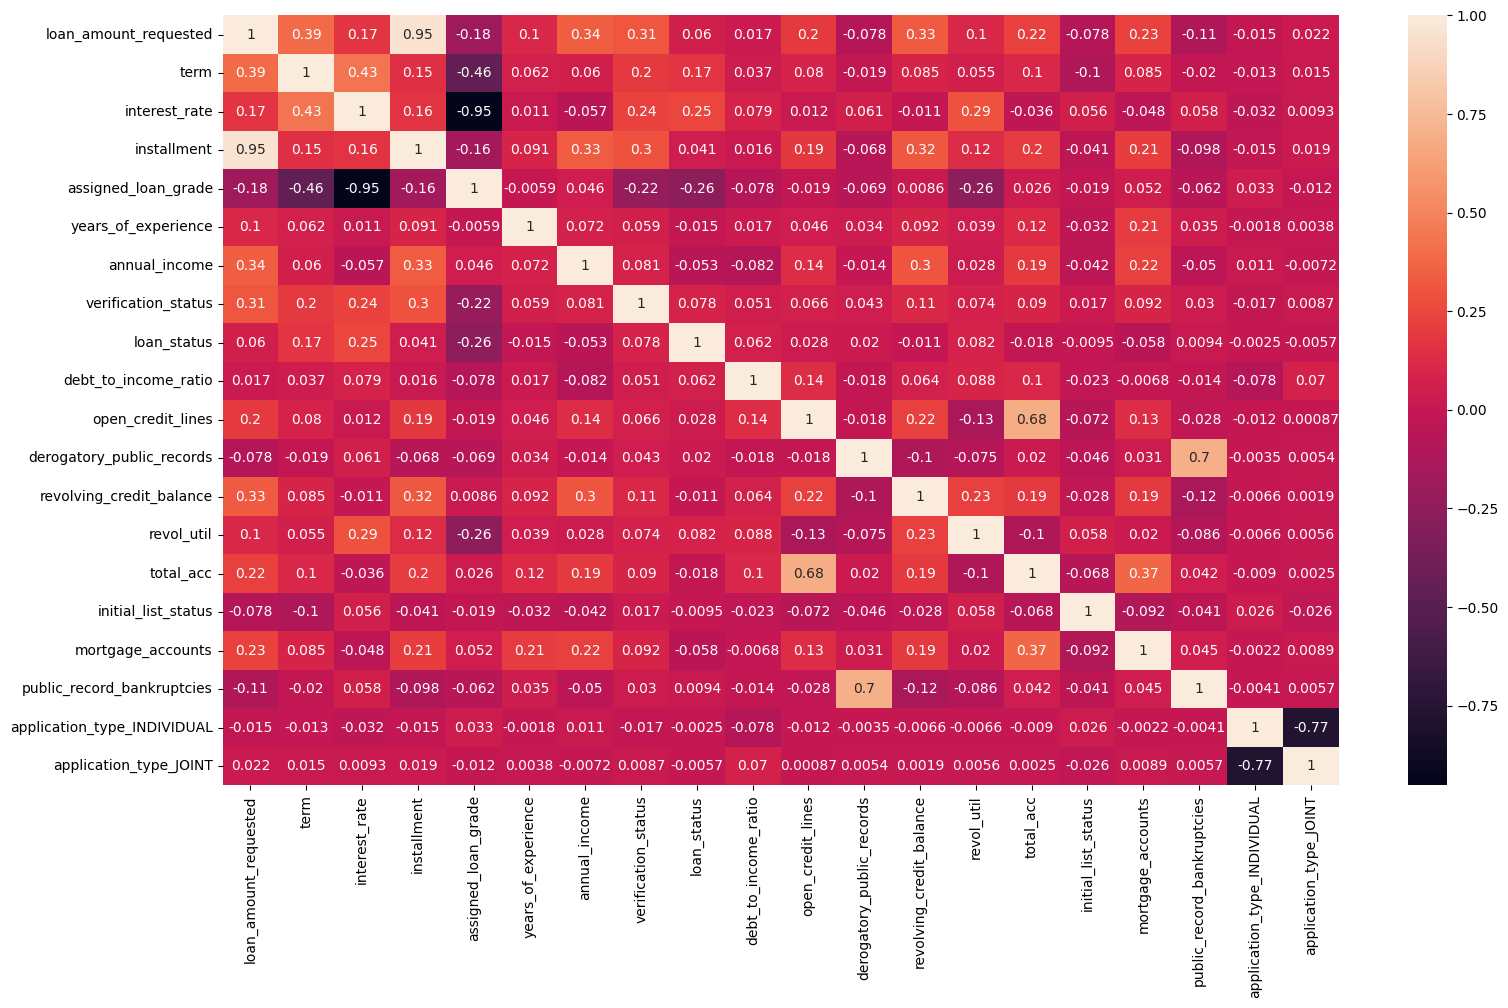

In [ ]:
plt.figure(figsize=(18, 10))
sns.heatmap(df_filtered.corr(), annot=True)

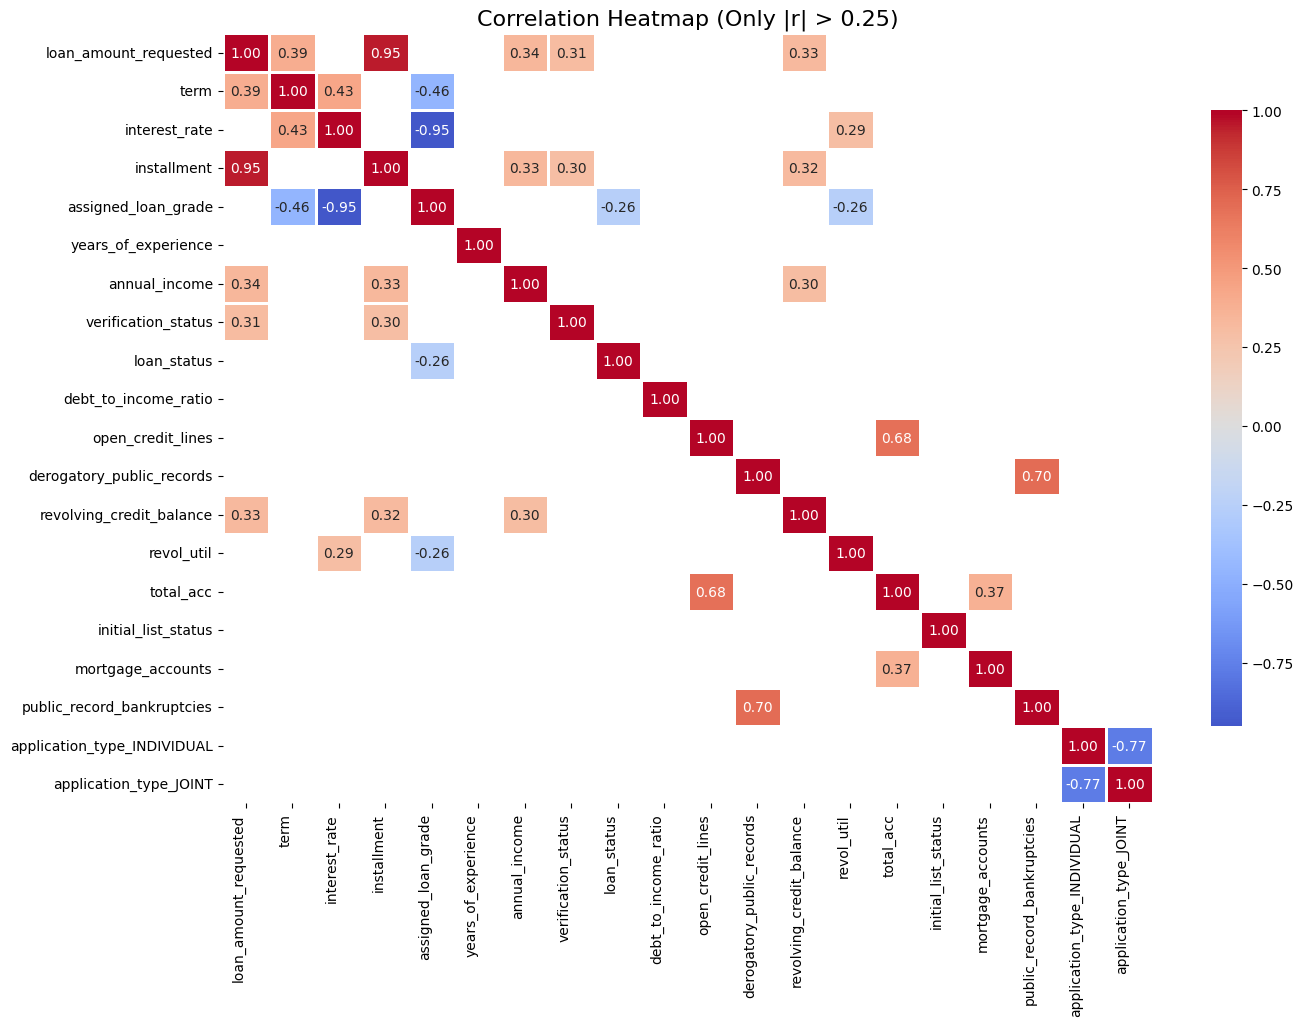

In [ ]:
corr = df_filtered.corr()
threshold = 0.25
mask = corr.abs() <= threshold

plt.figure(figsize=(15, 10))
sns.heatmap(corr,
            mask=mask,          # Apply the mask based on your logic
            annot=True,         # Show the numbers
            fmt=".2f",          # Limit to 2 decimal places
            cmap='coolwarm',    # Red for positive, Blue for negative
            center=0,           # Ensure 0 is the neutral color
            linewidths=1,      # Add thin lines between cells for readability
            cbar_kws={"shrink": .8})

plt.title(f"Correlation Heatmap (Only |r| > {threshold:.2f})", fontsize=16)
plt.xticks(ha='right')
plt.show()

### **Splitting the dataset into X and y variables**

In [ ]:
df_scaled = df_encoded.copy()

In [ ]:
X = df_scaled.drop(columns=['loan_status'])
y = df_scaled['loan_status']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

### **Scaling the dataset for further analysis**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled

array([[ 1.30259488, -0.55754195, -1.17161078, ..., -0.40910255,
        -0.16881671, -0.16996037],
       [-0.25273589, -0.55754195, -1.28337356, ..., -0.40910255,
        -0.16881671, -0.16996037],
       [ 1.08724139,  1.79358702,  0.08013229, ..., -0.40910255,
        -0.16881671, -0.16996037],
       ...,
       [ 0.17797109, -0.55754195, -0.31774319, ..., -0.40910255,
        -0.16881671, -0.16996037],
       [ 1.24576549, -0.55754195,  0.78423777, ..., -0.40910255,
        -0.16881671, -0.16996037],
       [ 0.1061866 ,  1.79358702,  0.44224368, ...,  2.4443749 ,
        -0.16881671, -0.16996037]])

In [ ]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression(solver='lbfgs', max_iter=1000, class_weight='balanced')
log_model.fit(X_train_scaled, y_train)
predictions = log_model.predict(X_test_scaled)

In [ ]:
# Create a dataframe to view coefficients alongside feature names
coeff_df = pd.DataFrame(log_model.coef_[0], X.columns, columns=['Coefficient'])
print(coeff_df.sort_values(by='Coefficient', ascending=False))

                             Coefficient
zip_code_11650                  3.197925
zip_code_93700                  3.177036
zip_code_86630                  3.151032
zip_code_70466                  2.864174
zip_code_22690                  2.860055
zip_code_48052                  2.857158
zip_code_30723                  2.852212
debt_to_income_ratio            0.497514
term                            0.207383
open_credit_lines               0.112524
installment                     0.090101
revol_util                      0.085847
derogatory_public_records       0.067655
interest_rate                   0.066564
home_ownership_RENT             0.065229
verification_status             0.040309
application_type_INDIVIDUAL     0.021159
home_ownership_OWN              0.013972
home_ownership_OTHER            0.004989
home_ownership_NONE             0.003272
initial_list_status            -0.014959
public_record_bankruptcies     -0.022642
application_type_JOINT         -0.023071
loan_amount_requ

In [ ]:
print(f"Model Intercept: {log_model.intercept_[0]}")

Model Intercept: -3.9842548975565295


### **Dimentionality Reduction**

### **Logistic Regression Model Metrics**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# 1. Print the Confusion Matrix
print("Confusion Matrix:")
print(confusion_matrix(y_test, predictions))

# 2. Print the Classification Report
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Confusion Matrix:
[[51460 12169]
 [ 3260 12317]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87     63629
           1       0.50      0.79      0.61     15577

    accuracy                           0.81     79206
   macro avg       0.72      0.80      0.74     79206
weighted avg       0.85      0.81      0.82     79206



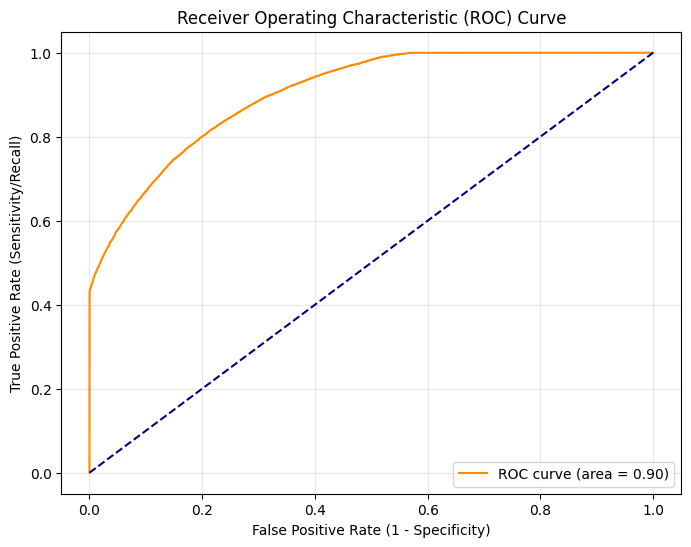

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# 1. Get the probabilities for the positive class (Charged Off)
# log_model.predict_proba returns [prob_0, prob_1]. We want index 1.
y_probs = log_model.predict_proba(X_test_scaled)[:, 1]

# 2. Calculate the ROC curve points
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

# 3. Calculate the AUC (Area Under the Curve)
auc_score = roc_auc_score(y_test, y_probs)

# 4. Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--') # The "Random Guess" line
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity/Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

### **Cross validation**

In [ ]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# 1. Define the algorithms to compare
models = {"Logistic Regression": LogisticRegression(max_iter=1000)
        , "Random Forest": RandomForestClassifier(n_estimators=100)
        , "Gradient Boosting": GradientBoostingClassifier()}

# 2. Set up Stratified K-Fold (5 folds is standard)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# 3. Iterate and evaluate
results = {}

for name, model in models.items():
    # We use 'roc_auc' as the metric since it's best for credit risk
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='roc_auc')
    results[name] = cv_scores
    print(f"{name} AUC: {np.mean(cv_scores):.4f} (+/- {np.std(cv_scores):.4f})")

Logistic Regression AUC: 0.9049 (+/- 0.0022)
Random Forest AUC: 0.8921 (+/- 0.0027)
Gradient Boosting AUC: 0.9008 (+/- 0.0026)


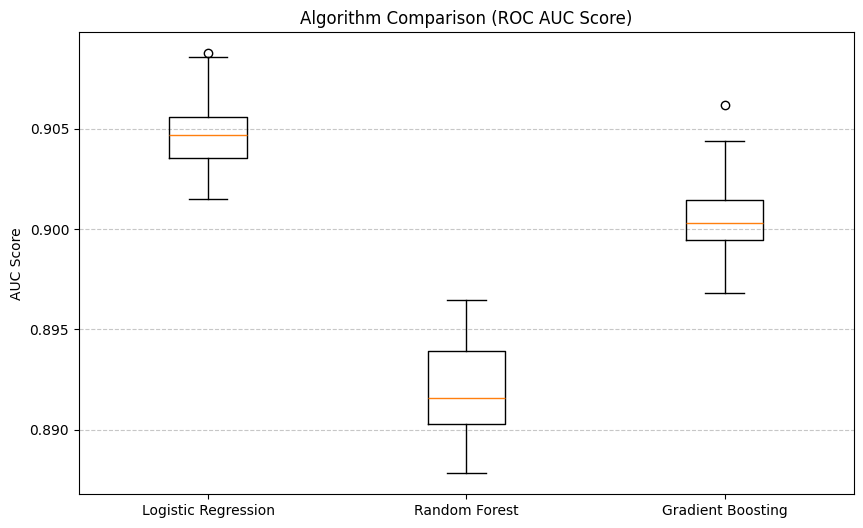

In [ ]:
plt.figure(figsize=(10, 6))
plt.boxplot(results.values(), tick_labels=results.keys())
plt.title('Algorithm Comparison (ROC AUC Score)')
plt.ylabel('AUC Score')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# 1. Define the parameter grid
# We test different 'depths' and 'estimators' to find the balance between learning and overfitting
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'bootstrap': [True]
}

# 2. Initialize the Grid Search
# We use 'roc_auc' because catching defaults is our primary goal
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=3, # 3-fold CV to keep it fast
                           scoring='roc_auc',
                           n_jobs=-1, # Uses all your CPU cores
                           verbose=2)

# 3. Fit the search to your scaled training data
grid_search.fit(X_train_scaled, y_train)

# 4. Get the best results
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation AUC: {grid_search.best_score_:.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Cross-Validation AUC: 0.8938


In [ ]:
# Use the best model found by Grid Search
final_model = grid_search.best_estimator_

# Check performance on the test set
final_probs = final_model.predict_proba(X_test_scaled)[:, 1]
final_auc = roc_auc_score(y_test, final_probs)

print(f"Final Test Set AUC: {final_auc:.4f}")

Final Test Set AUC: 0.8941
